## Data Loading and Price Range Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Housing.csv')
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/Housing.csv'

In [ ]:
# Define price ranges in lakhs
def categorize_price(price):
    price_lakhs = price / 100000
    if 0 <= price_lakhs <= 25:
        return '0-25 Lakhs'
    elif 26 <= price_lakhs <= 50:
        return '26-50 Lakhs'
    elif 51 <= price_lakhs <= 75:
        return '51-75 Lakhs'
    elif 76 <= price_lakhs <= 100:
        return '76-100 Lakhs'
    elif price_lakhs > 100:
        return '>100 Lakhs'
    return 'Invalid'

df['price_range'] = df['price'].apply(categorize_price)

# Count houses in each range
price_range_counts = df['price_range'].value_counts().sort_index()
display(price_range_counts)


,count
price_range,
0-25 Lakhs,32
26-50 Lakhs,312
51-75 Lakhs,141
76-100 Lakhs,36
>100 Lakhs,8
Invalid,16


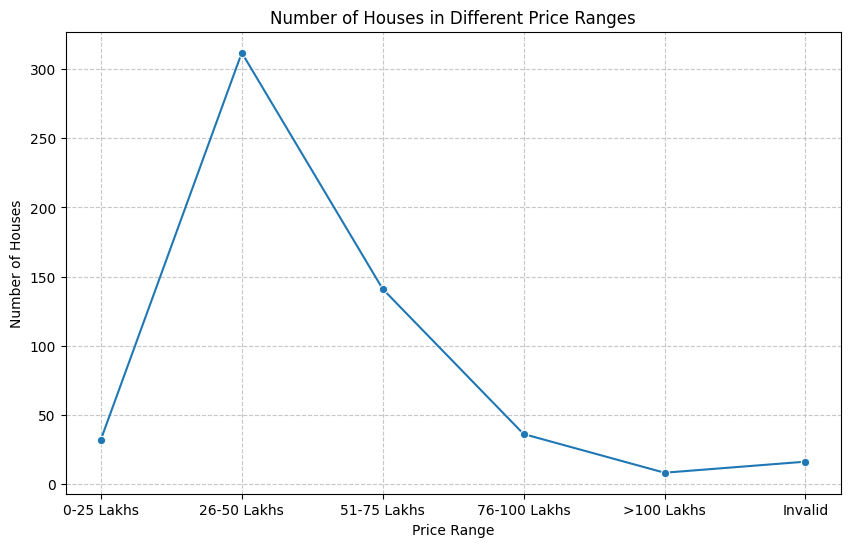

In [ ]:
# Visualize the counts using a line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x=price_range_counts.index, y=price_range_counts.values, marker='o')
plt.title('Number of Houses in Different Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Number of Houses')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Average House Prices: AC vs. Non-AC

In [ ]:
# Calculate average house prices for houses with and without AC
avg_price_ac = df.groupby('airconditioning')['price'].mean().reset_index()
avg_price_ac['price_lakhs'] = avg_price_ac['price'] / 100000
display(avg_price_ac)

,airconditioning,price,price_lakhs
0,no,4.191940e+06,41.919397
1,yes,6.013221e+06,60.132206


/tmp/ipykernel_1169/1720003612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airconditioning', y='price_lakhs', data=avg_price_ac, palette='viridis')


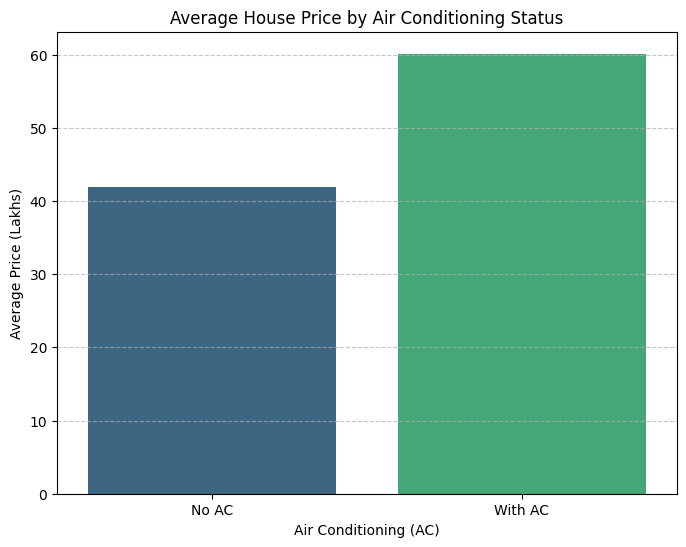

In [ ]:
# Plot the relationship using a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='airconditioning', y='price_lakhs', data=avg_price_ac, palette='viridis')
plt.title('Average House Price by Air Conditioning Status')
plt.xlabel('Air Conditioning (AC)')
plt.ylabel('Average Price (Lakhs)')
plt.xticks(ticks=[0, 1], labels=['No AC', 'With AC'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Relationship Between Parking and House Price

In [ ]:
# Calculate average house prices based on the number of parking spaces
avg_price_parking = df.groupby('parking')['price'].mean().reset_index()
avg_price_parking['price_lakhs'] = avg_price_parking['price'] / 100000
display(avg_price_parking)

,parking,price,price_lakhs
0,0,4.136017e+06,41.360167
1,1,5.190389e+06,51.903889
2,2,5.896328e+06,58.963281
3,3,5.867167e+06,58.671667


/tmp/ipykernel_1169/1196073942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='parking', y='price_lakhs', data=avg_price_parking, palette='viridis')


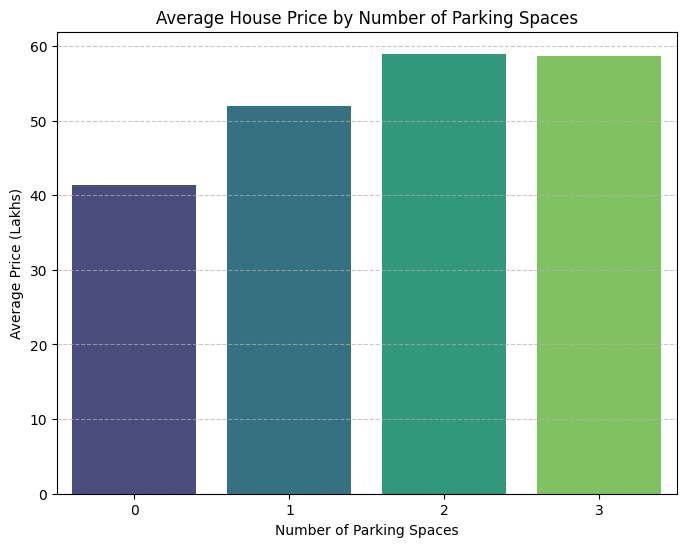

In [ ]:
# Plot the relationship using a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='parking', y='price_lakhs', data=avg_price_parking, palette='viridis')
plt.title('Average House Price by Number of Parking Spaces')
plt.xlabel('Number of Parking Spaces')
plt.ylabel('Average Price (Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Price Gap Analysis: Area and Preferred Area

In [ ]:
# Define the two groups based on the given conditions
# Group 1: houses having <5000sqft & no prefarea
condition_1 = (df['area'] < 5000) & (df['prefarea'] == 'no')
group_1_prices = df[condition_1]['price']

# Group 2: houses having >5000sqft & there is prefarea
condition_2 = (df['area'] > 5000) & (df['prefarea'] == 'yes')
group_2_prices = df[condition_2]['price']

# Calculate the average price for each group
avg_price_group_1 = group_1_prices.mean()
avg_price_group_2 = group_2_prices.mean()

# Calculate the price gap
price_gap = avg_price_group_2 - avg_price_group_1

print(f"Average price for houses <5000 sqft and no prefarea: {avg_price_group_1/100000:.2f} Lakhs")
print(f"Average price for houses >5000 sqft and with prefarea: {avg_price_group_2/100000:.2f} Lakhs")
print(f"Price gap (Group 2 - Group 1): {price_gap/100000:.2f} Lakhs")

Average price for houses <5000 sqft and no prefarea: 38.28 Lakhs
Average price for houses >5000 sqft and with prefarea: 65.47 Lakhs
Price gap (Group 2 - Group 1): 27.19 Lakhs
